# HPC Log Feature Extraction
This notebook performs feature extraction only on `HPC.log`.

Feature extraction methods are kept independent:
1. Manual structured features from parsed log fields
2. Template-based semantic features using `HPC_2k.log_templates.csv`
3. TF-IDF text features (with SVD only for visualization of the TF-IDF method)

In [32]:
from pathlib import Path
import re
import zipfile
from datetime import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

project_root = Path('..').resolve()
log_path = project_root / 'HPC.log'
if not log_path.exists():
    raise FileNotFoundError(f'Could not find HPC.log at {log_path}')

print('Project root:', project_root)
print('Log path:', log_path)

Project root: /Users/sidqian/Downloads/Code/log-ml
Log path: /Users/sidqian/Downloads/Code/log-ml/HPC.log


In [33]:
# Load raw log lines
raw_lines = log_path.read_text(errors='replace').splitlines()
df_raw = pd.DataFrame({'raw_line': raw_lines})

print('Total log lines:', len(df_raw))
display(df_raw.head(10))

Total log lines: 433490


,raw_line
0,460903 resourcemgmtdaeomon node-25 server subsys 1145552216 1 failed to configure resourcemgmt subsystem err = 10
1,460919 resourcemgmtdaeomon node-25 server subsys 1145552221 1 failed to configure resourcemgmt subsystem err = 10
2,460932 resourcemgmtdaeomon node-25 server subsys 1145552226 1 failed to configure resourcemgmt subsystem err = 10
3,460949 resourcemgmtdaeomon node-25 server subsys 1145552232 1 failed to configure resourcemgmt subsystem err = 10
4,460971 resourcemgmtdaeomon node-25 server subsys 1145552237 1 failed to configure resourcemgmt subsystem err = 10
5,462410 resourcemgmtdaeomon node-25 server subsys 1145552885 1 failed to configure resourcemgmt subsystem err = 10
6,462413 resourcemgmtdaeomon node-25 server subsys 1145552891 1 failed to configure resourcemgmt subsystem err = 10
7,462415 resourcemgmtdaeomon node-25 server subsys 1145552896 1 failed to configure resourcemgmt subsystem err = 10
8,462417 resourcemgmtdaeomon node-25 server subsys 1145552902 1 failed to configure resourcemgmt subsystem err = 10
9,462419 resourcemgmtdaeomon node-25 server subsys 1145552907 1 failed to configure resourcemgmt subsystem err = 10


## Inspect Log Format and Sample Records
This section checks the first records to confirm delimiters and the structure of each line before parsing.

In [34]:
sample_lines = raw_lines[:10]
for idx, line in enumerate(sample_lines, start=1):
    print(f'{idx:02d}: {line}')

sample_token_counts = [len(line.split()) for line in sample_lines]
print('Sample token counts:', sample_token_counts)

# The log looks like a fixed-prefix record with a free-text message tail.
# Expected structure: event_id component node role subsystem_tag timestamp severity message
print('Observed format hint: space-delimited fields with the final field containing the full message text.')

01: 460903 resourcemgmtdaeomon node-25 server subsys 1145552216 1 failed to configure resourcemgmt subsystem err = 10
02: 460919 resourcemgmtdaeomon node-25 server subsys 1145552221 1 failed to configure resourcemgmt subsystem err = 10
03: 460932 resourcemgmtdaeomon node-25 server subsys 1145552226 1 failed to configure resourcemgmt subsystem err = 10
04: 460949 resourcemgmtdaeomon node-25 server subsys 1145552232 1 failed to configure resourcemgmt subsystem err = 10
05: 460971 resourcemgmtdaeomon node-25 server subsys 1145552237 1 failed to configure resourcemgmt subsystem err = 10
06: 462410 resourcemgmtdaeomon node-25 server subsys 1145552885 1 failed to configure resourcemgmt subsystem err = 10
07: 462413 resourcemgmtdaeomon node-25 server subsys 1145552891 1 failed to configure resourcemgmt subsystem err = 10
08: 462415 resourcemgmtdaeomon node-25 server subsys 1145552896 1 failed to configure resourcemgmt subsystem err = 10
09: 462417 resourcemgmtdaeomon node-25 server subsys 114

## Parse Log Lines into Structured Columns
The parser uses a regular expression to split the fixed prefix from the free-text message.

In [35]:
# HPC log has multiple line schemas; parse both and merge
pattern_a = re.compile(
    r'^(?P<event_id>\d+)\s+'
    r'(?P<component>\S+)\s+'
    r'(?P<node>\S+)\s+'
    r'(?P<role>\S+)\s+'
    r'(?P<tag>\S+)\s+'
    r'(?P<timestamp_raw>\d+)\s+'
    r'(?P<severity>\d+)\s+'
    r'(?P<message>.*)$'
)

pattern_b = re.compile(
    r'^(?P<event_id>\d+)\s+'
    r'(?P<component>\S+)\s+'
    r'(?P<node>\S+)\s+'
    r'(?P<role>\S+)\s+'
    r'(?P<timestamp_raw>\d+)\s+'
    r'(?P<severity>\d+)\s+'
    r'(?P<message>.*)$'
)

parsed_a = df_raw['raw_line'].str.extract(pattern_a)
parsed_b = df_raw['raw_line'].str.extract(pattern_b)
parsed_b['tag'] = '-'

parsed = parsed_a.copy()
fallback_mask = parsed['event_id'].isna()
parsed.loc[fallback_mask, parsed.columns] = parsed_b.loc[fallback_mask, parsed.columns]

df = pd.concat([df_raw, parsed], axis=1)

df['parse_ok'] = df['event_id'].notna()
df['timestamp_raw'] = pd.to_numeric(df['timestamp_raw'], errors='coerce')
df['severity'] = pd.to_numeric(df['severity'], errors='coerce')

print('Parsed rows:', int(df['parse_ok'].sum()), '/', len(df))
print('Unparsed rows:', int((~df['parse_ok']).sum()))
print('Unique messages after parsing:', int(df.loc[df['parse_ok'], 'message'].nunique()))
print('Unique node values after parsing:', int(df.loc[df['parse_ok'], 'node'].nunique()))
display(df.head(10))

Parsed rows: 430278 / 433490
Unparsed rows: 3212
Unique messages after parsing: 9963
Unique node values after parsing: 15


,raw_line,event_id,component,node,role,tag,timestamp_raw,severity,message,parse_ok
0,460903 resourcemgmtdaeomon node-25 server subsys 1145552216 1 failed to configure resourcemgmt subsystem err = 10,460903,resourcemgmtdaeomon,node-25,server,subsys,1.145552e+09,1.0,failed to configure resourcemgmt subsystem err = 10,True
1,460919 resourcemgmtdaeomon node-25 server subsys 1145552221 1 failed to configure resourcemgmt subsystem err = 10,460919,resourcemgmtdaeomon,node-25,server,subsys,1.145552e+09,1.0,failed to configure resourcemgmt subsystem err = 10,True
2,460932 resourcemgmtdaeomon node-25 server subsys 1145552226 1 failed to configure resourcemgmt subsystem err = 10,460932,resourcemgmtdaeomon,node-25,server,subsys,1.145552e+09,1.0,failed to configure resourcemgmt subsystem err = 10,True
3,460949 resourcemgmtdaeomon node-25 server subsys 1145552232 1 failed to configure resourcemgmt subsystem err = 10,460949,resourcemgmtdaeomon,node-25,server,subsys,1.145552e+09,1.0,failed to configure resourcemgmt subsystem err = 10,True
4,460971 resourcemgmtdaeomon node-25 server subsys 1145552237 1 failed to configure resourcemgmt subsystem err = 10,460971,resourcemgmtdaeomon,node-25,server,subsys,1.145552e+09,1.0,failed to configure resourcemgmt subsystem err = 10,True
5,462410 resourcemgmtdaeomon node-25 server subsys 1145552885 1 failed to configure resourcemgmt subsystem err = 10,462410,resourcemgmtdaeomon,node-25,server,subsys,1.145553e+09,1.0,failed to configure resourcemgmt subsystem err = 10,True
6,462413 resourcemgmtdaeomon node-25 server subsys 1145552891 1 failed to configure resourcemgmt subsystem err = 10,462413,resourcemgmtdaeomon,node-25,server,subsys,1.145553e+09,1.0,failed to configure resourcemgmt subsystem err = 10,True
7,462415 resourcemgmtdaeomon node-25 server subsys 1145552896 1 failed to configure resourcemgmt subsystem err = 10,462415,resourcemgmtdaeomon,node-25,server,subsys,1.145553e+09,1.0,failed to configure resourcemgmt subsystem err = 10,True
8,462417 resourcemgmtdaeomon node-25 server subsys 1145552902 1 failed to configure resourcemgmt subsystem err = 10,462417,resourcemgmtdaeomon,node-25,server,subsys,1.145553e+09,1.0,failed to configure resourcemgmt subsystem err = 10,True
9,462419 resourcemgmtdaeomon node-25 server subsys 1145552907 1 failed to configure resourcemgmt subsystem err = 10,462419,resourcemgmtdaeomon,node-25,server,subsys,1.145553e+09,1.0,failed to configure resourcemgmt subsystem err = 10,True


In [36]:
template_path = project_root / 'HPC_2k.log_templates.csv'
if not template_path.exists():
    raise FileNotFoundError(f'Could not find template file at {template_path}')

templates_df = pd.read_csv(template_path)
templates_df['EventTemplate'] = templates_df['EventTemplate'].astype(str)

def template_to_regex(template: str) -> re.Pattern:
    normalized = template.replace('\\ ', ' ').replace('\\', '')
    regex_text = '^' + re.escape(normalized).replace(re.escape('<*>'), '(.+?)') + '$'
    return re.compile(regex_text, flags=re.IGNORECASE)

templates_df['template_regex'] = templates_df['EventTemplate'].apply(template_to_regex)

def match_template(message: str):
    message = '' if pd.isna(message) else str(message)
    for row in templates_df.itertuples(index=False):
        if row.template_regex.search(message):
            return pd.Series({'template_id': row.EventId, 'template_text': row.EventTemplate})
    return pd.Series({'template_id': 'UNKNOWN', 'template_text': 'UNKNOWN'})

template_matches = df['message'].apply(match_template)
df = pd.concat([df, template_matches], axis=1)

print('Template matches found:', int((df['template_id'] != 'UNKNOWN').sum()), '/', len(df))
display(df[['event_id', 'message', 'template_id', 'template_text']].head(20))

Template matches found: 425002 / 433490


,event_id,message,template_id,template_text
0,460903,failed to configure resourcemgmt subsystem err = 10,UNKNOWN,UNKNOWN
1,460919,failed to configure resourcemgmt subsystem err = 10,UNKNOWN,UNKNOWN
2,460932,failed to configure resourcemgmt subsystem err = 10,UNKNOWN,UNKNOWN
3,460949,failed to configure resourcemgmt subsystem err = 10,UNKNOWN,UNKNOWN
4,460971,failed to configure resourcemgmt subsystem err = 10,UNKNOWN,UNKNOWN
5,462410,failed to configure resourcemgmt subsystem err = 10,UNKNOWN,UNKNOWN
6,462413,failed to configure resourcemgmt subsystem err = 10,UNKNOWN,UNKNOWN
7,462415,failed to configure resourcemgmt subsystem err = 10,UNKNOWN,UNKNOWN
8,462417,failed to configure resourcemgmt subsystem err = 10,UNKNOWN,UNKNOWN
9,462419,failed to configure resourcemgmt subsystem err = 10,UNKNOWN,UNKNOWN


## Map Log Lines to Template Codes
Use `HPC_2k.log_templates.csv` to attach the normalized template id and template text to each parsed log message.

## Extract Timestamp and Time-Based Features
Convert the raw epoch timestamp into a datetime index and derive time-based features and event gaps.

In [37]:
df['datetime'] = pd.to_datetime(df['timestamp_raw'], unit='s', utc=True, errors='coerce')
df = df.sort_values(['node', 'component', 'datetime', 'event_id']).reset_index(drop=True)

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['weekday'] = df['datetime'].dt.weekday
df['date'] = df['datetime'].dt.date

df['time_since_prev_event_sec'] = df['datetime'].diff().dt.total_seconds()
df['time_since_prev_node_event_sec'] = df.groupby('node')['datetime'].diff().dt.total_seconds()
df['time_since_prev_component_event_sec'] = df.groupby('component')['datetime'].diff().dt.total_seconds()

display(df[['event_id', 'component', 'node', 'datetime', 'hour', 'weekday', 'time_since_prev_event_sec']].head(15))

,event_id,component,node,datetime,hour,weekday,time_since_prev_event_sec
0,2586534,node-0,action,2004-01-16 08:19:44+00:00,8.0,4.0,NaN
1,2586755,node-0,action,2004-01-16 08:23:45+00:00,8.0,4.0,241.0
2,2590114,node-0,action,2004-01-16 14:02:34+00:00,14.0,4.0,20329.0
3,2590114,node-0,action,2004-01-16 14:02:34+00:00,14.0,4.0,0.0
4,2590145,node-0,action,2004-01-16 14:05:04+00:00,14.0,4.0,150.0
5,2590145,node-0,action,2004-01-16 14:05:04+00:00,14.0,4.0,0.0
6,2598270,node-0,action,2004-01-16 23:30:57+00:00,23.0,4.0,33953.0
7,2598270,node-0,action,2004-01-16 23:30:57+00:00,23.0,4.0,0.0
8,2598334,node-0,action,2004-01-16 23:34:01+00:00,23.0,4.0,184.0
9,2598334,node-0,action,2004-01-16 23:34:01+00:00,23.0,4.0,0.0


## Extract Message, Severity, and Event-Type Features
Create text-derived indicators, severity flags, and message-length features from the log message tail.

In [38]:
message_text = df['message'].fillna('')
df['message_length'] = message_text.str.len()
df['message_word_count'] = message_text.str.split().str.len()
df['message_char_count'] = df['message_length']
df['message_upper_ratio'] = message_text.apply(lambda x: sum(ch.isupper() for ch in x) / len(x) if len(x) else 0.0)

keyword_map = {
    'has_error_word': r'\berror\b',
    'has_fail_word': r'\bfail(?:ed|ure)?\b',
    'has_warn_word': r'\bwarn(?:ing)?\b',
    'has_timeout_word': r'\btimeout\b',
    'has_configure_word': r'\bconfigure\b',
    'has_resource_word': r'\bresource(?:mgmt)?\b',
    'has_subsystem_word': r'\bsubsystem\b',
}

for feature_name, regex in keyword_map.items():
    df[feature_name] = message_text.str.contains(regex, case=False, regex=True).astype(int)

df['is_high_severity'] = (df['severity'] >= 2).astype(int)
df['event_type'] = np.select(
    [
        df['has_error_word'] == 1,
        df['has_fail_word'] == 1,
        df['has_warn_word'] == 1,
    ],
    ['error', 'failure', 'warning'],
    default='other'
 )

display(df[['event_id', 'severity', 'event_type', 'message_length', 'has_error_word', 'has_fail_word', 'has_warn_word']].head(15))

,event_id,severity,event_type,message_length,has_error_word,has_fail_word,has_warn_word
0,2586534,1.0,other,20,0,0,0
1,2586755,1.0,other,20,0,0,0
2,2590114,1.0,other,20,0,0,0
3,2590114,1.0,other,20,0,0,0
4,2590145,1.0,other,20,0,0,0
5,2590145,1.0,other,20,0,0,0
6,2598270,1.0,other,20,0,0,0
7,2598270,1.0,other,20,0,0,0
8,2598334,1.0,other,20,0,0,0
9,2598334,1.0,other,20,0,0,0


## Aggregate Features by Session, Host, or Job
The HPC log does not expose a true session or job id in the sampled records, so we aggregate by host/node and component as stable entities.

In [39]:
entity_cols = ['node', 'component']
agg_df = (
    df.groupby(entity_cols)
    .agg(
        event_count=('event_id', 'count'),
        severity_mean=('severity', 'mean'),
        severity_max=('severity', 'max'),
        message_length_mean=('message_length', 'mean'),
        message_length_std=('message_length', 'std'),
        error_rate=('has_error_word', 'mean'),
        fail_rate=('has_fail_word', 'mean'),
        warning_rate=('has_warn_word', 'mean'),
        high_severity_rate=('is_high_severity', 'mean'),
        unique_roles=('role', 'nunique'),
        unique_tags=('tag', 'nunique'),
        first_event_time=('datetime', 'min'),
        last_event_time=('datetime', 'max'),
    )
    .reset_index()
 )

agg_df['active_span_sec'] = (agg_df['last_event_time'] - agg_df['first_event_time']).dt.total_seconds()
agg_df['events_per_hour'] = agg_df['event_count'] / (agg_df['active_span_sec'].replace(0, np.nan) / 3600.0)
agg_df['events_per_hour'] = agg_df['events_per_hour'].replace([np.inf, -np.inf], np.nan).fillna(0)

display(agg_df.head(20))

,node,component,event_count,severity_mean,severity_max,message_length_mean,message_length_std,error_rate,fail_rate,warning_rate,high_severity_rate,unique_roles,unique_tags,first_event_time,last_event_time,active_span_sec,events_per_hour
0,action,node-0,150,1.0,1.0,24.640000,15.901239,0.080000,0.080000,0.0,0.0,3,1,2004-01-16 08:19:44+00:00,2006-04-20 16:50:03+00:00,71310619.0,0.007573
1,action,node-1,146,1.0,1.0,23.417808,13.549784,0.054795,0.047945,0.0,0.0,2,1,2004-01-14 23:47:35+00:00,2006-04-20 16:50:17+00:00,71427762.0,0.007358
2,action,node-10,140,1.0,1.0,21.385714,8.317085,0.021429,0.021429,0.0,0.0,2,1,2004-01-14 22:47:55+00:00,2006-04-20 16:54:45+00:00,71431610.0,0.007056
3,action,node-100,105,1.0,1.0,21.895238,9.845854,0.028571,0.019048,0.0,0.0,2,1,2004-01-14 22:34:57+00:00,2006-04-20 16:50:50+00:00,71432153.0,0.005292
4,action,node-101,101,1.0,1.0,20.782178,5.654386,0.009901,0.000000,0.0,0.0,2,1,2004-01-14 22:34:57+00:00,2006-04-20 16:51:03+00:00,71432166.0,0.005090
5,action,node-102,95,1.0,1.0,20.831579,5.828493,0.010526,0.010526,0.0,0.0,2,1,2004-01-14 22:34:57+00:00,2006-04-20 16:51:06+00:00,71432169.0,0.004788
6,action,node-103,93,1.0,1.0,20.849462,5.890202,0.010753,0.010753,0.0,0.0,2,1,2004-01-14 22:34:57+00:00,2006-04-20 16:51:00+00:00,71432163.0,0.004687
7,action,node-104,93,1.0,1.0,20.849462,5.890202,0.010753,0.010753,0.0,0.0,2,1,2004-01-14 22:34:57+00:00,2006-04-20 17:05:23+00:00,71433026.0,0.004687
8,action,node-105,93,1.0,1.0,20.849462,5.890202,0.010753,0.010753,0.0,0.0,2,1,2004-01-14 22:38:19+00:00,2006-04-20 16:55:18+00:00,71432219.0,0.004687
9,action,node-106,93,1.0,1.0,20.849462,5.890202,0.010753,0.010753,0.0,0.0,2,1,2004-01-14 22:41:09+00:00,2006-04-20 16:54:58+00:00,71432029.0,0.004687


## Build the Final Feature Table
Combine the parsed record-level features with the entity-level aggregates into a clean feature matrix.

In [40]:
final_features = df.merge(agg_df, on=['node', 'component'], how='left', suffixes=('', '_entity'))

selected_columns = [
    'event_id', 'template_id', 'template_text', 'component', 'node', 'role', 'tag', 'datetime', 'severity', 'message',
    'hour', 'day', 'weekday', 'time_since_prev_event_sec', 'time_since_prev_node_event_sec',
    'time_since_prev_component_event_sec', 'message_length', 'message_word_count',
    'message_upper_ratio', 'has_error_word', 'has_fail_word', 'has_warn_word',
    'has_timeout_word', 'has_configure_word', 'has_resource_word', 'has_subsystem_word',
    'is_high_severity', 'event_type', 'event_count', 'severity_mean', 'severity_max',
    'message_length_mean', 'message_length_std', 'error_rate', 'fail_rate',
    'warning_rate', 'high_severity_rate', 'unique_roles', 'unique_tags', 'active_span_sec',
    'events_per_hour',
 ]

final_features = final_features[selected_columns].copy()

print('Final feature rows:', len(final_features))
display(final_features.head(20))

Final feature rows: 433490


,event_id,template_id,template_text,component,node,role,tag,datetime,severity,message,hour,day,weekday,time_since_prev_event_sec,time_since_prev_node_event_sec,time_since_prev_component_event_sec,message_length,message_word_count,message_upper_ratio,has_error_word,has_fail_word,has_warn_word,has_timeout_word,has_configure_word,has_resource_word,has_subsystem_word,is_high_severity,event_type,event_count,severity_mean,severity_max,message_length_mean,message_length_std,error_rate,fail_rate,warning_rate,high_severity_rate,unique_roles,unique_tags,active_span_sec,events_per_hour
0,2586534,E4,boot (command <*>),node-0,action,start,-,2004-01-16 08:19:44+00:00,1.0,boot (command 1927),8.0,16.0,4.0,NaN,NaN,NaN,20,3,0.0,0,0,0,0,0,0,0,0,other,150.0,1.0,1.0,24.64,15.901239,0.08,0.08,0.0,0.0,3.0,1.0,71310619.0,0.007573
1,2586755,E45,wait (command <*>),node-0,action,start,-,2004-01-16 08:23:45+00:00,1.0,wait (command 1927),8.0,16.0,4.0,241.0,241.0,241.0,20,3,0.0,0,0,0,0,0,0,0,0,other,150.0,1.0,1.0,24.64,15.901239,0.08,0.08,0.0,0.0,3.0,1.0,71310619.0,0.007573
2,2590114,E4,boot (command <*>),node-0,action,start,-,2004-01-16 14:02:34+00:00,1.0,boot (command 1950),14.0,16.0,4.0,20329.0,20329.0,20329.0,20,3,0.0,0,0,0,0,0,0,0,0,other,150.0,1.0,1.0,24.64,15.901239,0.08,0.08,0.0,0.0,3.0,1.0,71310619.0,0.007573
3,2590114,E4,boot (command <*>),node-0,action,start,-,2004-01-16 14:02:34+00:00,1.0,boot (command 1950),14.0,16.0,4.0,0.0,0.0,0.0,20,3,0.0,0,0,0,0,0,0,0,0,other,150.0,1.0,1.0,24.64,15.901239,0.08,0.08,0.0,0.0,3.0,1.0,71310619.0,0.007573
4,2590145,E45,wait (command <*>),node-0,action,start,-,2004-01-16 14:05:04+00:00,1.0,wait (command 1950),14.0,16.0,4.0,150.0,150.0,150.0,20,3,0.0,0,0,0,0,0,0,0,0,other,150.0,1.0,1.0,24.64,15.901239,0.08,0.08,0.0,0.0,3.0,1.0,71310619.0,0.007573
5,2590145,E45,wait (command <*>),node-0,action,start,-,2004-01-16 14:05:04+00:00,1.0,wait (command 1950),14.0,16.0,4.0,0.0,0.0,0.0,20,3,0.0,0,0,0,0,0,0,0,0,other,150.0,1.0,1.0,24.64,15.901239,0.08,0.08,0.0,0.0,3.0,1.0,71310619.0,0.007573
6,2598270,E4,boot (command <*>),node-0,action,start,-,2004-01-16 23:30:57+00:00,1.0,boot (command 1957),23.0,16.0,4.0,33953.0,33953.0,33953.0,20,3,0.0,0,0,0,0,0,0,0,0,other,150.0,1.0,1.0,24.64,15.901239,0.08,0.08,0.0,0.0,3.0,1.0,71310619.0,0.007573
7,2598270,E4,boot (command <*>),node-0,action,start,-,2004-01-16 23:30:57+00:00,1.0,boot (command 1957),23.0,16.0,4.0,0.0,0.0,0.0,20,3,0.0,0,0,0,0,0,0,0,0,other,150.0,1.0,1.0,24.64,15.901239,0.08,0.08,0.0,0.0,3.0,1.0,71310619.0,0.007573
8,2598334,E45,wait (command <*>),node-0,action,start,-,2004-01-16 23:34:01+00:00,1.0,wait (command 1957),23.0,16.0,4.0,184.0,184.0,184.0,20,3,0.0,0,0,0,0,0,0,0,0,other,150.0,1.0,1.0,24.64,15.901239,0.08,0.08,0.0,0.0,3.0,1.0,71310619.0,0.007573
9,2598334,E45,wait (command <*>),node-0,action,start,-,2004-01-16 23:34:01+00:00,1.0,wait (command 1957),23.0,16.0,4.0,0.0,0.0,0.0,20,3,0.0,0,0,0,0,0,0,0,0,other,150.0,1.0,1.0,24.64,15.901239,0.08,0.08,0.0,0.0,3.0,1.0,71310619.0,0.007573


## Export Extracted Features for Downstream Modeling
Save the parsed records and final feature table so later notebooks can reuse this output directly.

## TF-IDF Visualization with TruncatedSVD
Reduce the TF-IDF matrix to 2 dimensions so the log messages can be visualized in a scatter plot.

## TF-IDF Feature Summary
Use the reduced TF-IDF features to inspect log text structure in a compact form.

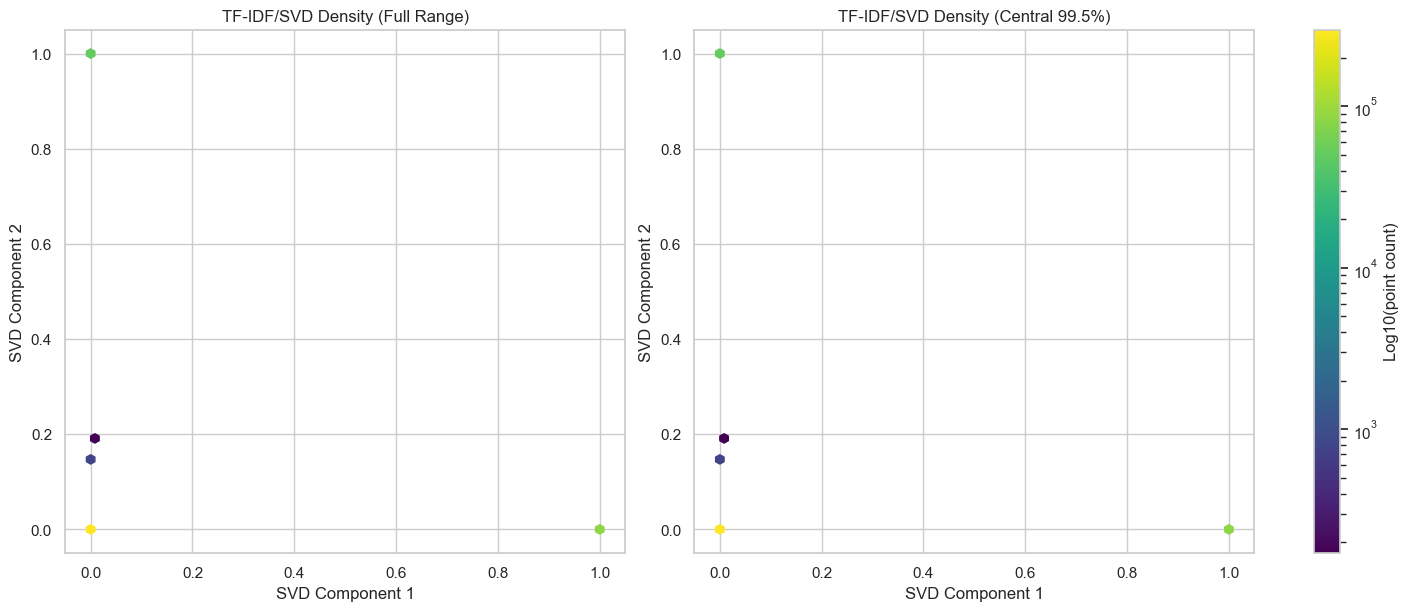

TF-IDF matrix shape used for SVD: (433490, 300)
Explained variance ratio: [0.17335773 0.11178723]
Unique SVD points (exact): 1124
Unique SVD points (rounded 6dp): 18
Zoom kept rows: 433490 of 433490
Saved visualization to: /Users/sidqian/Downloads/Code/log-ml/artifacts/hpc_log_feature_extraction/hpc_tfidf_svd_visualization.png


In [51]:
# Recompute TF-IDF in this cell so SVD visualization is deterministic on full reruns
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_features=300,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['message'].fillna(''))

svd_model = TruncatedSVD(n_components=2, random_state=42)
tfidf_2d = svd_model.fit_transform(tfidf_matrix)

tfidf_2d_df = pd.DataFrame(tfidf_2d, columns=['svd_1', 'svd_2'])
tfidf_2d_df['event_type'] = df['event_type'].to_numpy()

x = tfidf_2d_df['svd_1'].to_numpy()
y = tfidf_2d_df['svd_2'].to_numpy()

x_clip = np.quantile(np.abs(x), 0.995)
y_clip = np.quantile(np.abs(y), 0.995)
if x_clip == 0:
    x_clip = max(np.max(np.abs(x)), 1e-6)
if y_clip == 0:
    y_clip = max(np.max(np.abs(y)), 1e-6)

zoom_mask = (np.abs(x) <= x_clip) & (np.abs(y) <= y_clip)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

hb_full = axes[0].hexbin(
    x,
    y,
    gridsize=60,
    bins='log',
    mincnt=1,
    cmap='viridis',
)
axes[0].set_title('TF-IDF/SVD Density (Full Range)')
axes[0].set_xlabel('SVD Component 1')
axes[0].set_ylabel('SVD Component 2')

hb_zoom = axes[1].hexbin(
    x[zoom_mask],
    y[zoom_mask],
    gridsize=60,
    bins='log',
    mincnt=1,
    cmap='viridis',
)
axes[1].set_title('TF-IDF/SVD Density (Central 99.5%)')
axes[1].set_xlabel('SVD Component 1')
axes[1].set_ylabel('SVD Component 2')

cb = fig.colorbar(hb_zoom, ax=axes.ravel().tolist())
cb.set_label('Log10(point count)')

tfidf_viz_path = project_root / 'artifacts' / 'hpc_log_feature_extraction' / 'hpc_tfidf_svd_visualization.png'
tfidf_viz_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(tfidf_viz_path, dpi=200, bbox_inches='tight')
plt.show()

n_unique_exact = tfidf_2d_df[['svd_1', 'svd_2']].drop_duplicates().shape[0]
n_unique_r6 = tfidf_2d_df[['svd_1', 'svd_2']].round(6).drop_duplicates().shape[0]
print('TF-IDF matrix shape used for SVD:', tfidf_matrix.shape)
print('Explained variance ratio:', svd_model.explained_variance_ratio_)
print('Unique SVD points (exact):', n_unique_exact)
print('Unique SVD points (rounded 6dp):', n_unique_r6)
print('Zoom kept rows:', int(zoom_mask.sum()), 'of', len(zoom_mask))
print('Saved visualization to:', tfidf_viz_path)

In [47]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_features=300,
 )

tfidf_matrix = tfidf_vectorizer.fit_transform(df['message'].fillna(''))
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print('TF-IDF matrix shape:', tfidf_matrix.shape)
print('Top TF-IDF terms sample:', list(tfidf_feature_names[:20]))

TF-IDF matrix shape: (433490, 300)
Top TF-IDF terms sample: ['00', '0000', '0000 042', '0001', '01000010', '01000010 6005', '042', '042 available', '042 unavailable', '042alt0', '042alt0 042', '042scsi', '042scsi wwid', '047t', '047t send', '08b4', '08b4 0001', '0x0000000e', '0x0000000e ok', '0x000001fe']


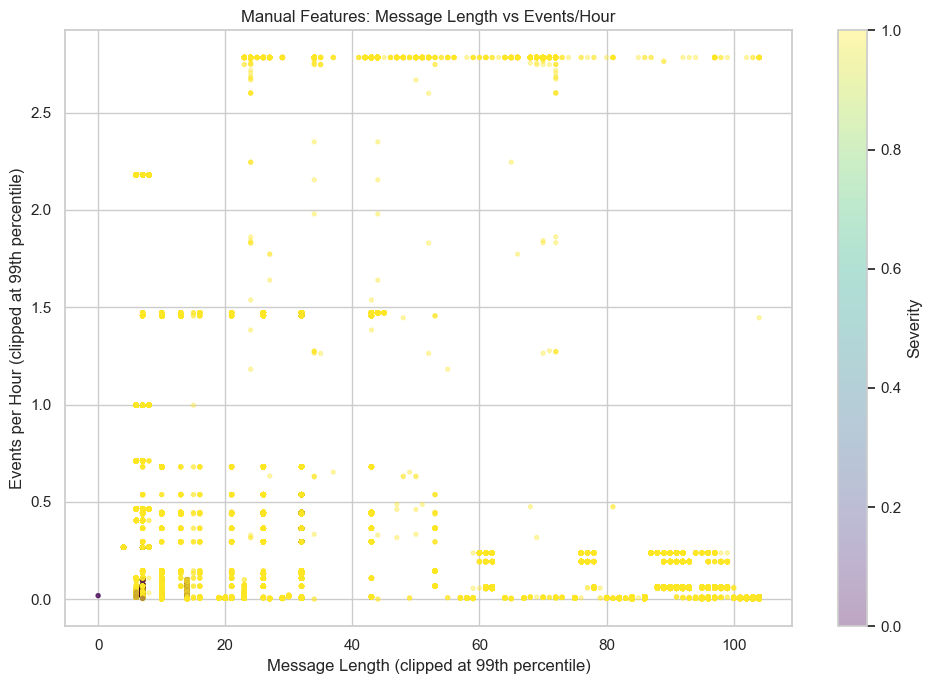

Saved independent manual-feature visualization to: /Users/sidqian/Downloads/Code/log-ml/artifacts/hpc_log_feature_extraction/hpc_manual_feature_scatter.png


In [48]:
# Independent manual-feature visualization (no secondary extraction on manual features)
manual_vis_df = final_features.copy()

plt.figure(figsize=(10, 7))
plt.scatter(
    manual_vis_df['message_length'].clip(upper=manual_vis_df['message_length'].quantile(0.99)),
    manual_vis_df['events_per_hour'].clip(upper=manual_vis_df['events_per_hour'].quantile(0.99)),
    c=manual_vis_df['severity'],
    cmap='viridis',
    s=8,
    alpha=0.35,
)
plt.colorbar(label='Severity')
plt.title('Manual Features: Message Length vs Events/Hour')
plt.xlabel('Message Length (clipped at 99th percentile)')
plt.ylabel('Events per Hour (clipped at 99th percentile)')
plt.tight_layout()

manual_feature_viz_path = project_root / 'artifacts' / 'hpc_log_feature_extraction' / 'hpc_manual_feature_scatter.png'
manual_feature_viz_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(manual_feature_viz_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved independent manual-feature visualization to:', manual_feature_viz_path)

## Manual Feature Visualization (Independent Method)
This plot visualizes manual features directly without applying another feature-extraction method on top.

## Text Feature Extraction with TF-IDF
Create sparse text features from the log message field for analysis and visualization.

In [52]:
artifacts_dir = project_root / 'artifacts' / 'hpc_log_feature_extraction'
artifacts_dir.mkdir(parents=True, exist_ok=True)

parsed_path = artifacts_dir / 'hpc_log_parsed_records.csv'
features_path = artifacts_dir / 'hpc_log_features.csv'

df.to_csv(parsed_path, index=False)
final_features.to_csv(features_path, index=False)

print('Saved parsed records to:', parsed_path)
print('Saved final feature table to:', features_path)

Saved parsed records to: /Users/sidqian/Downloads/Code/log-ml/artifacts/hpc_log_feature_extraction/hpc_log_parsed_records.csv
Saved final feature table to: /Users/sidqian/Downloads/Code/log-ml/artifacts/hpc_log_feature_extraction/hpc_log_features.csv


## Export Artifact Bundle
Save the requested sample dataset, feature code notebook, feature tables, and visualizations under `artifacts/`.

In [53]:
artifacts_dir = project_root / 'artifacts' / 'hpc_log_feature_extraction'
artifacts_dir.mkdir(parents=True, exist_ok=True)

sample_path = artifacts_dir / 'hpc_log_sample.csv'
tfidf_features_path = artifacts_dir / 'hpc_tfidf_svd_features.csv'
code_zip_path = artifacts_dir / 'hpc_log_feature_extraction_code.zip'
visualization_path = manual_feature_viz_path

sample_df = df[['raw_line', 'event_id', 'template_id', 'template_text', 'severity', 'message']].head(1000).copy()
sample_df.to_csv(sample_path, index=False)
tfidf_2d_df.to_csv(tfidf_features_path, index=False)

notebook_path = project_root / 'notebooks' / '03_hpc_log_feature_extract.ipynb'
with zipfile.ZipFile(code_zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(notebook_path, arcname=notebook_path.name)

print('Saved sample dataset to:', sample_path)
print('Saved TF-IDF/SVD features to:', tfidf_features_path)
print('Saved code zip to:', code_zip_path)
print('Saved visualization to:', visualization_path)
print('Saved parsed records to:', parsed_path)
print('Saved final feature table to:', features_path)

Saved sample dataset to: /Users/sidqian/Downloads/Code/log-ml/artifacts/hpc_log_feature_extraction/hpc_log_sample.csv
Saved TF-IDF/SVD features to: /Users/sidqian/Downloads/Code/log-ml/artifacts/hpc_log_feature_extraction/hpc_tfidf_svd_features.csv
Saved code zip to: /Users/sidqian/Downloads/Code/log-ml/artifacts/hpc_log_feature_extraction/hpc_log_feature_extraction_code.zip
Saved visualization to: /Users/sidqian/Downloads/Code/log-ml/artifacts/hpc_log_feature_extraction/hpc_manual_feature_scatter.png
Saved parsed records to: /Users/sidqian/Downloads/Code/log-ml/artifacts/hpc_log_feature_extraction/hpc_log_parsed_records.csv
Saved final feature table to: /Users/sidqian/Downloads/Code/log-ml/artifacts/hpc_log_feature_extraction/hpc_log_features.csv
